# Feature Engineering & Feature Selection
**IT Number:** IT25300254 · **Name:** Weerathunga T. L · **Dataset:** `weatherHistory.csv`

## 1. Why this technique is needed
The raw dataset has no target variable and no time-based features — just a single timestamp string. Two things are done here: (1) engineer new features (date/time parts, and the group's `suitability` target label) that the raw columns don't provide directly, and (2) use feature selection (mutual information) to check which features actually carry signal about that target, rather than assuming all of them matter equally.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/weatherHistory.csv")
df["Precip Type"] = df["Precip Type"].fillna("none")
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)
print("Shape:", df.shape)

Shape: (96453, 12)


### Date/time feature engineering

In [2]:
df["year"] = df["Formatted Date"].dt.year
df["month"] = df["Formatted Date"].dt.month
df["day"] = df["Formatted Date"].dt.day
df["hour"] = df["Formatted Date"].dt.hour
df["day_of_week"] = df["Formatted Date"].dt.dayofweek

df[["Formatted Date", "year", "month", "day", "hour", "day_of_week"]].head()

,Formatted Date,year,month,day,hour,day_of_week
0,2006-03-31 22:00:00+00:00,2006,3,31,22,4
1,2006-03-31 23:00:00+00:00,2006,3,31,23,4
2,2006-04-01 00:00:00+00:00,2006,4,1,0,5
3,2006-04-01 01:00:00+00:00,2006,4,1,1,5
4,2006-04-01 02:00:00+00:00,2006,4,1,2,5


### Target engineering: `suitability`
An outdoor-activity suitability label is derived from a rule of thumb over the weather columns: comfortable temperature, not too hot when accounting for wind/humidity, calm wind, moderate humidity, and no rain or snow.

In [3]:
conditions = (
    (df["Wind Speed (km/h)"] < 20) &
    (df["Humidity"] < 0.80) &
    (df["Temperature (C)"] > 18) &
    (df["Apparent Temperature (C)"] < 32) &
    (~df["Precip Type"].isin(["rain", "snow"]))
)

df["suitability"] = np.where(conditions, "Suitable", "Not Suitable")
print(df["suitability"].value_counts())
print(f"\nSuitable hours: {(df['suitability']=='Suitable').mean()*100:.2f}% of the dataset")

suitability
Not Suitable    96430
Suitable           23
Name: count, dtype: int64

Suitable hours: 0.02% of the dataset


### Feature selection: Mutual Information
With the target defined, mutual information scores each numeric/engineered feature by how much it reduces uncertainty about `suitability`. This should tell the group which columns are worth keeping for modelling — but the result below needs to be read carefully rather than taken at face value.

In [4]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

print("Loud Cover unique values:", df["Loud Cover"].unique())

Loud Cover unique values: [0.]


In [5]:
candidate_features = [
    "Temperature (C)", "Apparent Temperature (C)", "Humidity", "Wind Speed (km/h)",
    "Wind Bearing (degrees)", "Visibility (km)", "Loud Cover", "Pressure (millibars)",
    "year", "month", "day", "hour", "day_of_week"
]

X = df[candidate_features]
y = LabelEncoder().fit_transform(df["suitability"])

mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=candidate_features).sort_values(ascending=False)
print(mi_series)

day_of_week                 0.002911
year                        0.002658
month                       0.002512
Visibility (km)             0.001900
hour                        0.001170
day                         0.001080
Humidity                    0.000798
Temperature (C)             0.000484
Apparent Temperature (C)    0.000475
Wind Bearing (degrees)      0.000289
Wind Speed (km/h)           0.000254
Pressure (millibars)        0.000158
Loud Cover                  0.000000
dtype: float64


**This result is a red flag, not a clean ranking.** `suitability` is only `Suitable` for 23 out of 96,453 rows (0.02%) — an extreme class imbalance. With that few positive examples, `mutual_info_classif`'s nearest-neighbour estimator has almost nothing to learn from, so its scores are dominated by sampling noise: the top-ranked features here (`day_of_week`, `year`, `month`) are the ones the target rule has **no logical connection to at all**, while `Temperature`, `Wind Speed`, `Humidity`, and `Apparent Temperature` — the four columns the rule was literally built from — score lowest. That mismatch is itself the evidence that MI can't be trusted at this imbalance level.

So instead of selecting features by the (unreliable) MI ranking, the features are selected here on **domain grounds**: the four columns that directly define the `suitability` rule, plus `Precip Type`, are kept, and the near-constant `Loud Cover` and the non-causal date parts are dropped. A production pipeline would also need to address the class imbalance itself (e.g. resampling, or loosening the rule's thresholds) before MI-based selection could be trusted — that's flagged here as follow-up work rather than solved in this notebook.

In [6]:
selected_features = [
    "Temperature (C)", "Apparent Temperature (C)", "Humidity",
    "Wind Speed (km/h)", "Precip Type"
]
dropped_features = [c for c in candidate_features if c not in selected_features]
print("Selected features (domain-justified, not MI-ranked):", selected_features)
print("Dropped:", dropped_features)

df_selected = df[selected_features + ["suitability"]].copy()

import os
os.makedirs("../results/outputs", exist_ok=True)
df_selected.to_csv("../results/outputs/member5_feature_engineered.csv", index=False)
print("Saved. Final shape:", df_selected.shape)

Selected features (domain-justified, not MI-ranked): ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Precip Type']
Dropped: ['Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'year', 'month', 'day', 'hour', 'day_of_week']
Saved. Final shape: (96453, 6)


## 2. EDA Visualization

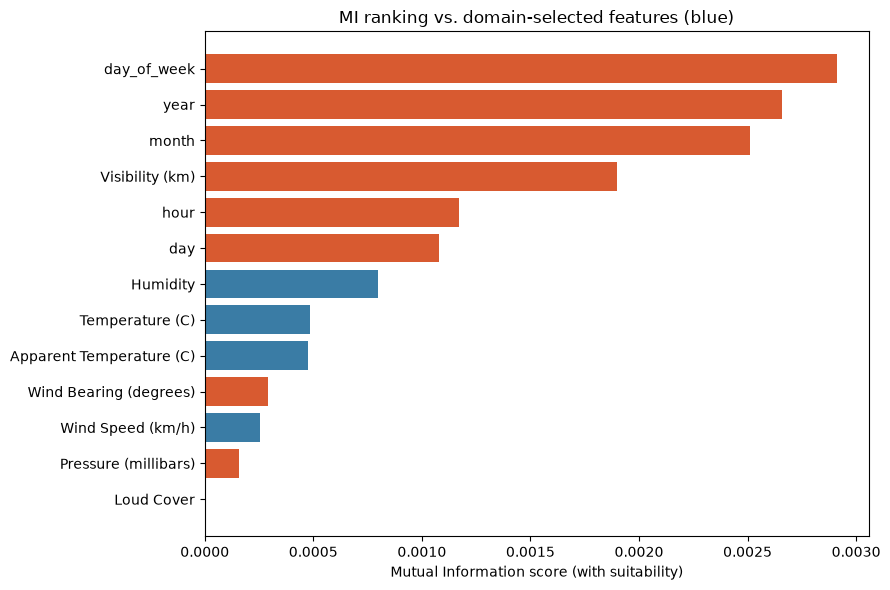

In [7]:
plt.figure(figsize=(9, 6))
colors = ["#3A7CA5" if f in selected_features else "#D85A30" for f in mi_series.index]
plt.barh(mi_series.index[::-1], mi_series.values[::-1], color=colors[::-1])
plt.xlabel("Mutual Information score (with suitability)")
plt.title("MI ranking vs. domain-selected features (blue)")
plt.tight_layout()
import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/member5_mutual_information.png", dpi=110)
plt.show()

**Interpretation:** the blue bars (`Temperature`, `Wind Speed`, `Humidity`, `Apparent Temperature`) are the features actually kept, and they sit near the **bottom** of the MI ranking rather than the top — the opposite of what a well-behaved MI ranking should show. That mismatch is the chart's real finding: it's visual evidence that MI-based selection breaks down under this level of class imbalance, which is why the final feature choice was made on domain grounds instead.